# Unit III Practical: Hierarchical Clustering & DBSCAN

**Aim:** To implement and visualize Hierarchical Clustering and DBSCAN using the built-in Iris dataset and compare the results with K-Means.

### Syllabus covered
- Agglomerative Hierarchical Clustering
- Single, Complete, Average and Ward linkage
- Dendrogram interpretation
- DBSCAN
- ε-neighborhood (`eps`)
- MinPts (`min_samples`)
- Core, Border and Noise points
- Comparison of K-Means, Hierarchical Clustering and DBSCAN

**Dataset:** Iris dataset from `sklearn.datasets` — no external download required.


In [13]:
# Step 1: Import libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage


## 1. Load the Iris Dataset

In [14]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)


Dataset shape: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


## 2. Standardize the Data

Clustering algorithms use distances between points. Standardization puts all features on a comparable scale.

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized successfully.")


Data standardized successfully.


## 3. Agglomerative Hierarchical Clustering

The four linkage methods in the syllabus are demonstrated below: **Single, Complete, Average and Ward**.

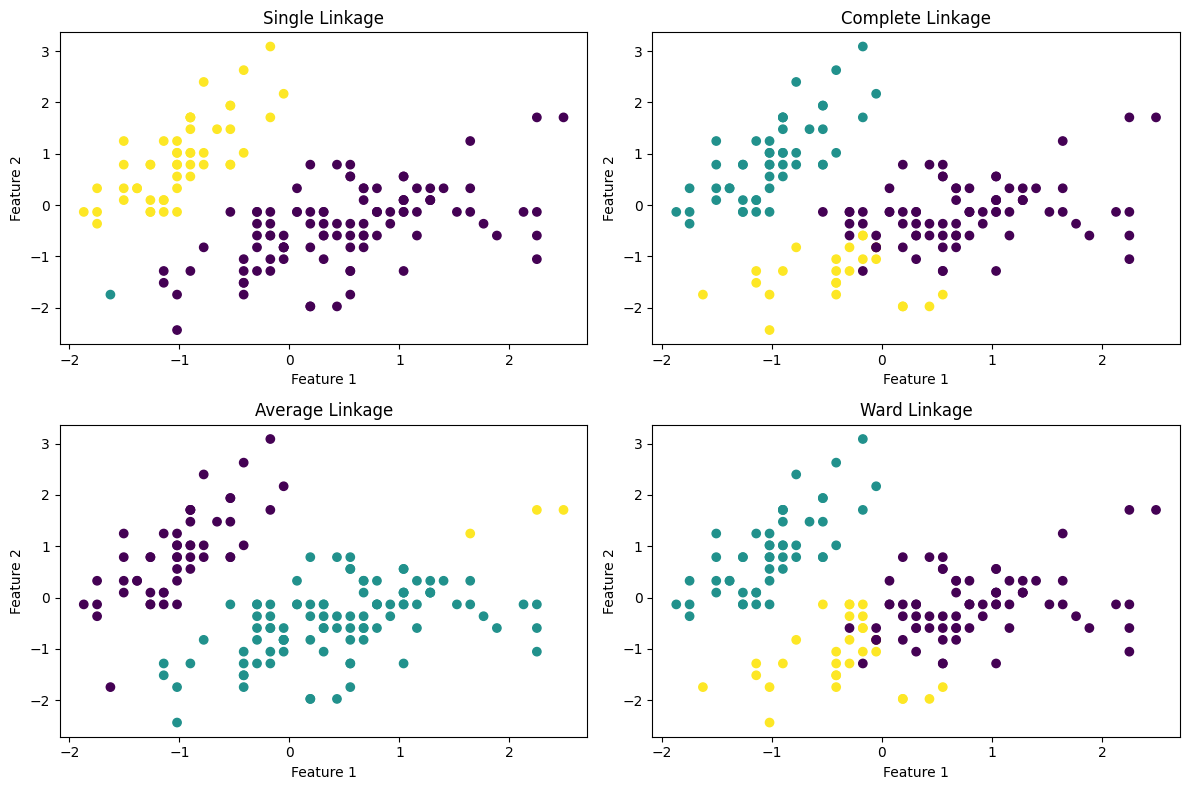

In [16]:
linkage_methods = ["single", "complete", "average", "ward"]

plt.figure(figsize=(12, 8))

for i, method in enumerate(linkage_methods):
    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )

    labels = model.fit_predict(X_scaled)

    plt.subplot(2, 2, i + 1)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
    plt.title(method.capitalize() + " Linkage")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()


### Linkage Methods

- **Single linkage:** distance between the closest pair of points.
- **Complete linkage:** distance between the farthest pair of points.
- **Average linkage:** average distance between points in two clusters.
- **Ward linkage:** merges clusters while minimizing the increase in within-cluster variance.


## 4. Dendrogram

A dendrogram shows the order in which observations/clusters are merged. A horizontal cut can be used to choose the number of clusters.

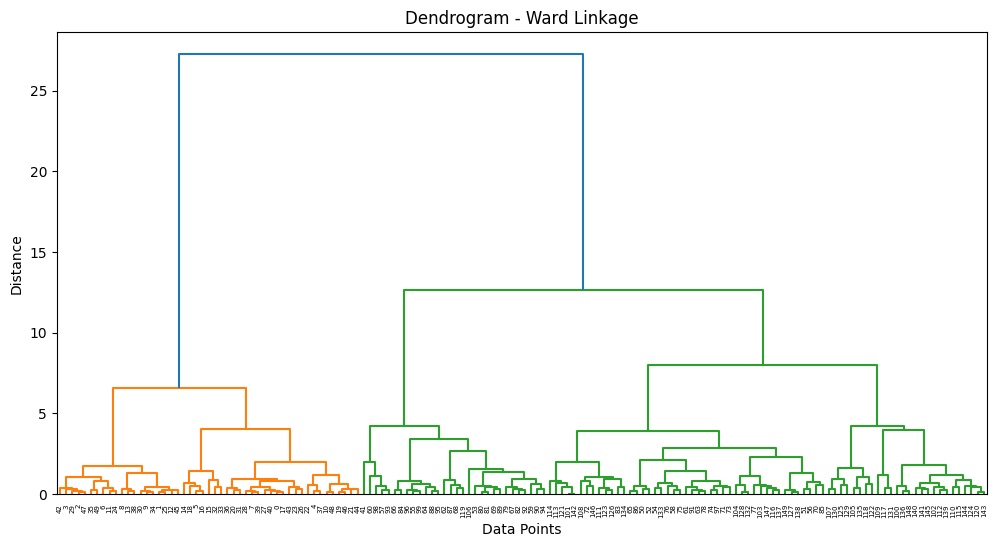

In [17]:
plt.figure(figsize=(12, 6))

Z = linkage(X_scaled, method="ward")

dendrogram(Z)

plt.title("Dendrogram - Ward Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


## 5. DBSCAN

DBSCAN is a density-based clustering algorithm.

- `eps` = radius of the ε-neighborhood.
- `min_samples` = MinPts, the minimum number of points required in the neighborhood.
- Label `-1` represents noise.


In [18]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster labels:")
print(dbscan_labels)


DBSCAN cluster labels:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]


## 6. Visualize DBSCAN Clusters

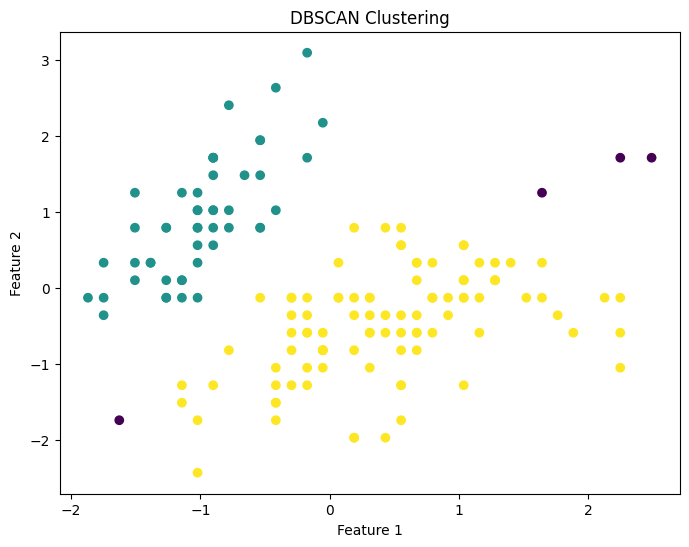

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=dbscan_labels
)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 7. Identify Noise Points

In DBSCAN, points assigned the label `-1` are noise points.

In [20]:
noise_indices = np.where(dbscan_labels == -1)[0]

print("Number of noise points:", len(noise_indices))
print("Noise point indices:", noise_indices)


Number of noise points: 4
Noise point indices: [ 41 109 117 131]


## 8. Identify Core and Border Points

Scikit-learn provides the indices of core samples. Points that are neither core nor noise are treated as border points.

In [21]:
core_indices = dbscan.core_sample_indices_

all_indices = np.arange(len(X_scaled))

border_indices = np.setdiff1d(
    all_indices,
    np.concatenate([core_indices, noise_indices])
)

print("Number of core points:", len(core_indices))
print("Number of border points:", len(border_indices))
print("Number of noise points:", len(noise_indices))


Number of core points: 138
Number of border points: 8
Number of noise points: 4


## 9. Visualize Core, Border and Noise Points

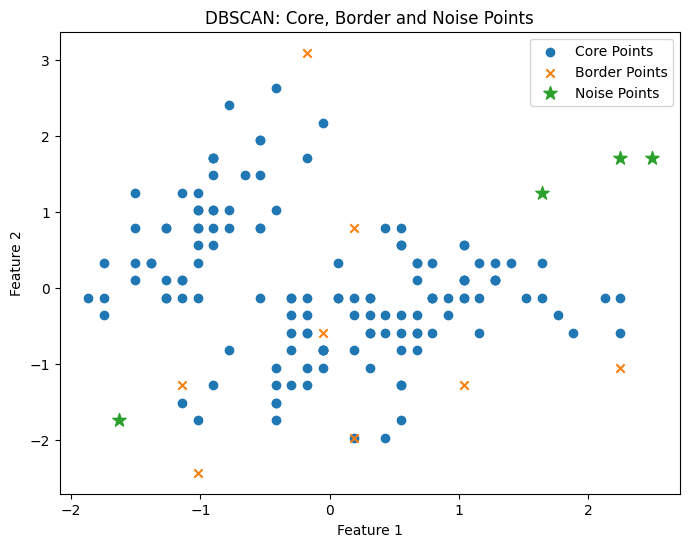

In [22]:
plt.figure(figsize=(8, 6))

# Core points
plt.scatter(
    X_scaled[core_indices, 0],
    X_scaled[core_indices, 1],
    label="Core Points"
)

# Border points
plt.scatter(
    X_scaled[border_indices, 0],
    X_scaled[border_indices, 1],
    marker="x",
    label="Border Points"
)

# Noise points
plt.scatter(
    X_scaled[noise_indices, 0],
    X_scaled[noise_indices, 1],
    marker="*",
    s=100,
    label="Noise Points"
)

plt.title("DBSCAN: Core, Border and Noise Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


## 10. Compare K-Means, Hierarchical Clustering and DBSCAN

In [23]:
# K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# DBSCAN
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)
dbscan_labels = dbscan.fit_predict(X_scaled)


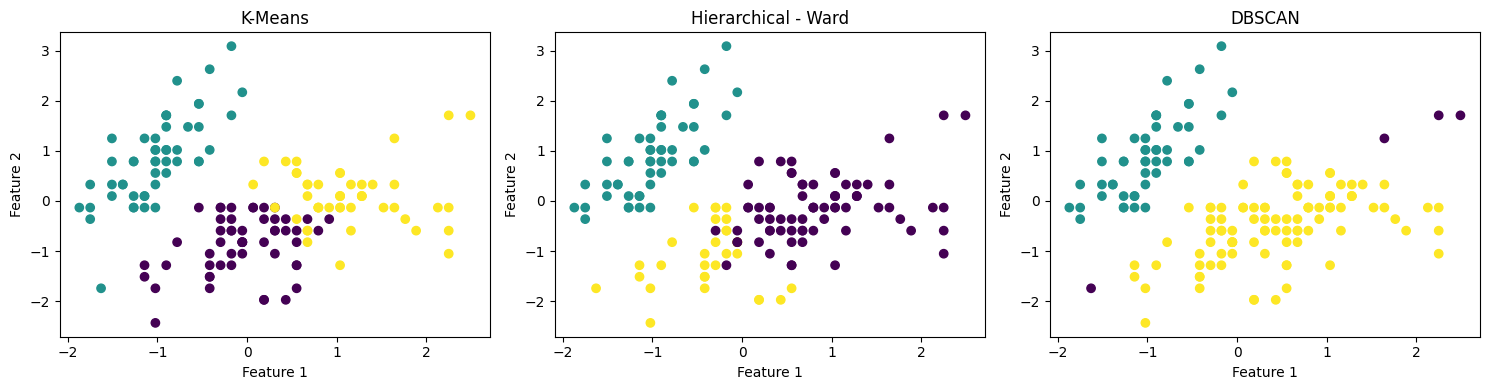

In [24]:
plt.figure(figsize=(15, 4))

# K-Means
plt.subplot(1, 3, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("K-Means")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Hierarchical
plt.subplot(1, 3, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hierarchical_labels)
plt.title("Hierarchical - Ward")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# DBSCAN
plt.subplot(1, 3, 3)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels)
plt.title("DBSCAN")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()


## 11. Quick Comparison

| Algorithm | Main idea | Number of clusters required beforehand? | Handles noise? |
|---|---|---:|---:|
| K-Means | Centroid-based | Yes | No |
| Hierarchical | Tree of merged/split clusters | Not necessarily | Not explicitly |
| DBSCAN | Density-based | No | Yes |

## Conclusion

Hierarchical Clustering and DBSCAN were successfully implemented on the Iris dataset. Different linkage methods and a dendrogram were used to understand hierarchical clustering. DBSCAN was used to identify clusters, core points, border points and noise points. The results were also compared with K-Means.
